In [22]:
import pandas as pd

# Read the admission data as CSV (this one is correct)
admission = pd.read_csv("/Users/ayushh.h/Downloads/HDHI Admission data.csv")

# Read the other files as CSV since they appear to be CSV files with .xls extensions
mortality = pd.read_csv("/Users/ayushh.h/Downloads/HDHI Mortality Data.csv.xls")
pollution = pd.read_csv("/Users/ayushh.h/Downloads/HDHI Pollution Data.csv.xls")


In [25]:
print("Admission Columns:")
print(admission.columns.tolist())

print("\nMortality Columns:")
print(mortality.columns.tolist())

print("\nPollution Columns:")
print(pollution.columns.tolist())

Admission Columns:
['SNO', 'MRD No.', 'D.O.A', 'D.O.D', 'AGE', 'GENDER', 'RURAL', 'TYPE OF ADMISSION-EMERGENCY/OPD', 'month year', 'DURATION OF STAY', 'duration of intensive unit stay', 'OUTCOME', 'SMOKING ', 'ALCOHOL', 'DM', 'HTN', 'CAD', 'PRIOR CMP', 'CKD', 'HB', 'TLC', 'PLATELETS', 'GLUCOSE', 'UREA', 'CREATININE', 'BNP', 'RAISED CARDIAC ENZYMES', 'EF', 'SEVERE ANAEMIA', 'ANAEMIA', 'STABLE ANGINA', 'ACS', 'STEMI', 'ATYPICAL CHEST PAIN', 'HEART FAILURE', 'HFREF', 'HFNEF', 'VALVULAR', 'CHB', 'SSS', 'AKI', 'CVA INFRACT', 'CVA BLEED', 'AF', 'VT', 'PSVT', 'CONGENITAL', 'UTI', 'NEURO CARDIOGENIC SYNCOPE', 'ORTHOSTATIC', 'INFECTIVE ENDOCARDITIS', 'DVT', 'CARDIOGENIC SHOCK', 'SHOCK', 'PULMONARY EMBOLISM', 'CHEST INFECTION']

Mortality Columns:
['S.NO', 'MRD', 'AGE', 'GENDER ', 'RURAL/URBAN', 'DATE OF BROUGHT DEAD']

Pollution Columns:
['DATE\tAQI\tPM2.5 AVG\tPM2.5 MIN\tPM2.5 MAX\tPM10 AVG\tPM10 MIN\tPM10 MAX\tNO2 AVG\tNO2 MIN\tNO2 MAX\tNH3 AVG\tNH3 MIN\tNH3 MAX\tSO2 AVG\tSO2 MIN\tSO2 MAX\tCO

In [27]:
pollution = pd.read_csv(
    "/Users/ayushh.h/Downloads/HDHI Pollution Data.csv.xls",
    sep="\t"
)

In [28]:
print(pollution.columns.tolist())

['DATE', 'AQI', 'PM2.5 AVG', 'PM2.5 MIN', 'PM2.5 MAX', 'PM10 AVG', 'PM10 MIN', 'PM10 MAX', 'NO2 AVG', 'NO2 MIN', 'NO2 MAX', 'NH3 AVG', 'NH3 MIN', 'NH3 MAX', 'SO2 AVG', 'SO2 MIN', 'SO2 MAX', 'CO AVG', 'CO MIN', 'CO MAX', 'OZONE AVG', 'OZONE MIN', 'OZONE MAX', 'PROMINENT POLLUTENT', 'MAX TEMP', 'MIN TEMP', 'HUMIDITY']


In [29]:
admission['D.O.A'] = pd.to_datetime(
    admission['D.O.A'],
    dayfirst=True,
    errors='coerce'
)

admission['D.O.D'] = pd.to_datetime(
    admission['D.O.D'],
    dayfirst=True,
    errors='coerce'
)

In [30]:
mortality['DATE OF BROUGHT DEAD'] = pd.to_datetime(
    mortality['DATE OF BROUGHT DEAD'],
    dayfirst=True,
    errors='coerce'
)

In [31]:
pollution['DATE'] = pd.to_datetime(
    pollution['DATE'],
    dayfirst=True,
    errors='coerce'
)

/var/folders/b5/3pmv91ws4z59f27_4r75x0kc0000gn/T/ipykernel_65544/3462103341.py:1: UserWarning: Parsing dates in %m/%d/%Y format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  pollution['DATE'] = pd.to_datetime(


In [32]:
print(admission[['D.O.A','D.O.D']].head())

print(mortality['DATE OF BROUGHT DEAD'].head())

print(pollution['DATE'].head())

       D.O.A      D.O.D
0 2017-01-04 2017-03-04
1 2017-01-04 2017-05-04
2 2017-01-04 2017-03-04
3 2017-01-04 2017-08-04
4 2017-01-04        NaT
0   2017-02-04
1   2017-02-04
2   2017-04-04
3   2017-06-04
4   2017-08-04
Name: DATE OF BROUGHT DEAD, dtype: datetime64[ns]
0   2017-03-25
1   2017-03-26
2   2017-03-27
3   2017-03-28
4   2017-03-29
Name: DATE, dtype: datetime64[ns]


In [33]:
print("Admission D.O.A Missing:",
      admission['D.O.A'].isna().sum())

print("Admission D.O.D Missing:",
      admission['D.O.D'].isna().sum())

print("Mortality Date Missing:",
      mortality['DATE OF BROUGHT DEAD'].isna().sum())

print("Pollution Date Missing:",
      pollution['DATE'].isna().sum())

Admission D.O.A Missing: 3767
Admission D.O.D Missing: 3770
Mortality Date Missing: 217
Pollution Date Missing: 288


In [34]:
print(admission.shape)
print(mortality.shape)
print(pollution.shape)

(15757, 56)
(359, 6)
(737, 27)


In [35]:
print("Admission Duplicates:", admission.duplicated().sum())

print("Mortality Duplicates:", mortality.duplicated().sum())

print("Pollution Duplicates:", pollution.duplicated().sum())

Admission Duplicates: 0
Mortality Duplicates: 0
Pollution Duplicates: 0


In [36]:
admission.isnull().sum().sort_values(ascending=False).head(20)

BNP                    8441
D.O.D                  3770
D.O.A                  3767
EF                     1505
GLUCOSE                 863
TLC                     286
PLATELETS               285
HB                      252
CREATININE              247
UREA                    241
AKI                       0
SSS                       0
CHB                       0
VALVULAR                  0
HFNEF                     0
HFREF                     0
SNO                       0
CVA BLEED                 0
CVA INFRACT               0
ATYPICAL CHEST PAIN       0
dtype: int64

In [37]:
mortality.isnull().sum()

S.NO                      0
MRD                       0
AGE                       0
GENDER                    0
RURAL/URBAN               0
DATE OF BROUGHT DEAD    217
dtype: int64

In [38]:
pollution.isnull().sum().sort_values(ascending=False)

DATE                   288
HUMIDITY                 4
PM2.5 AVG                0
SO2 MIN                  0
MIN TEMP                 0
MAX TEMP                 0
PROMINENT POLLUTENT      0
OZONE MAX                0
OZONE MIN                0
OZONE AVG                0
CO MAX                   0
CO MIN                   0
CO AVG                   0
SO2 MAX                  0
SO2 AVG                  0
PM2.5 MIN                0
AQI                      0
NH3 MIN                  0
NH3 AVG                  0
NO2 MAX                  0
NO2 MIN                  0
NO2 AVG                  0
PM10 MAX                 0
PM10 MIN                 0
PM10 AVG                 0
PM2.5 MAX                0
NH3 MAX                  0
dtype: int64

In [39]:
admission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15757 entries, 0 to 15756
Data columns (total 56 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   SNO                              15757 non-null  int64         
 1   MRD No.                          15757 non-null  object        
 2   D.O.A                            11990 non-null  datetime64[ns]
 3   D.O.D                            11987 non-null  datetime64[ns]
 4   AGE                              15757 non-null  int64         
 5   GENDER                           15757 non-null  object        
 6   RURAL                            15757 non-null  object        
 7   TYPE OF ADMISSION-EMERGENCY/OPD  15757 non-null  object        
 8   month year                       15757 non-null  object        
 9   DURATION OF STAY                 15757 non-null  int64         
 10  duration of intensive unit stay  15757 non-null  int64    

In [40]:
pollution.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737 entries, 0 to 736
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE                 449 non-null    datetime64[ns]
 1   AQI                  737 non-null    int64         
 2   PM2.5 AVG            737 non-null    int64         
 3   PM2.5 MIN            737 non-null    int64         
 4   PM2.5 MAX            737 non-null    int64         
 5   PM10 AVG             737 non-null    int64         
 6   PM10 MIN             737 non-null    int64         
 7   PM10 MAX             737 non-null    object        
 8   NO2 AVG              737 non-null    int64         
 9   NO2 MIN              737 non-null    int64         
 10  NO2 MAX              737 non-null    object        
 11  NH3 AVG              737 non-null    int64         
 12  NH3 MIN              737 non-null    int64         
 13  NH3 MAX              737 non-null  

In [41]:
admission['AGE'].describe()

count    15757.000000
mean        61.426160
std         13.420862
min          4.000000
25%         54.000000
50%         62.000000
75%         70.000000
max        110.000000
Name: AGE, dtype: float64

In [42]:
admission['GENDER'].value_counts()

GENDER
M    9990
F    5767
Name: count, dtype: int64

In [43]:
admission['RURAL'].value_counts()

RURAL
U    12077
R     3680
Name: count, dtype: int64

In [44]:
admission['OUTCOME'].value_counts()

OUTCOME
DISCHARGE    13756
EXPIRY        1105
DAMA           896
Name: count, dtype: int64

In [45]:
disease_cols = [
    'DM',
    'HTN',
    'CAD',
    'CKD',
    'HEART FAILURE',
    'STEMI',
    'AKI'
]

admission[disease_cols].sum().sort_values(ascending=False)

CAD              10551
HTN               7656
DM                5097
HEART FAILURE     4561
AKI               3504
STEMI             2202
CKD               1550
dtype: int64

In [46]:
admission['DURATION OF STAY'].describe()

count    15757.000000
mean         6.415054
std          5.011421
min          1.000000
25%          3.000000
50%          5.000000
75%          8.000000
max         98.000000
Name: DURATION OF STAY, dtype: float64

In [47]:
admission['duration of intensive unit stay'].describe()

count    15757.00000
mean         3.80377
std          4.01564
min          0.00000
25%          1.00000
50%          3.00000
75%          5.00000
max         58.00000
Name: duration of intensive unit stay, dtype: float64

In [48]:
admission['Age_Group'] = pd.cut(
    admission['AGE'],
    bins=[0,18,35,50,65,100],
    labels=['0-18','19-35','36-50','51-65','65+']
)

In [49]:
admission['Age_Group'].value_counts()

Age_Group
51-65    6779
65+      5980
36-50    2353
19-35     570
0-18       73
Name: count, dtype: int64

In [50]:
admission = pd.read_csv("/Users/ayushh.h/Downloads/HDHI Admission data.csv")

mortality = pd.read_csv("/Users/ayushh.h/Downloads/HDHI Mortality Data.csv.xls")

pollution = pd.read_csv(
    "/Users/ayushh.h/Downloads/HDHI Pollution Data.csv.xls",
    sep="\t"
)

In [51]:
admission['D.O.A'] = pd.to_datetime(
    admission['D.O.A'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

admission['D.O.D'] = pd.to_datetime(
    admission['D.O.D'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

In [52]:
mortality['DATE OF BROUGHT DEAD'] = pd.to_datetime(
    mortality['DATE OF BROUGHT DEAD'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

In [53]:
pollution['DATE'] = pd.to_datetime(
    pollution['DATE'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

In [54]:
print(admission['D.O.A'].isna().sum())
print(admission['D.O.D'].isna().sum())

print(mortality['DATE OF BROUGHT DEAD'].isna().sum())

print(pollution['DATE'].isna().sum())

0
1
0
0


In [55]:
daily_admissions = (
    admission
    .groupby('D.O.A')
    .size()
    .reset_index(name='Admissions')
)

daily_admissions.head()

,D.O.A,Admissions
0,2017-01-04,29
1,2017-01-05,28
2,2017-01-06,21
3,2017-01-07,11
4,2017-01-08,25


In [56]:
daily_deaths = (
    mortality
    .groupby('DATE OF BROUGHT DEAD')
    .size()
    .reset_index(name='Deaths')
)

daily_deaths.head()

,DATE OF BROUGHT DEAD,Deaths
0,2017-01-05,2
1,2017-01-10,1
2,2017-01-11,1
3,2017-01-12,1
4,2017-02-04,2


In [57]:
print("Admissions:")
print(daily_admissions['D.O.A'].min())
print(daily_admissions['D.O.A'].max())

print("Deaths:")
print(daily_deaths['DATE OF BROUGHT DEAD'].min())
print(daily_deaths['DATE OF BROUGHT DEAD'].max())

print("Pollution:")
print(pollution['DATE'].min())
print(pollution['DATE'].max())

Admissions:
2017-01-04 00:00:00
2019-12-03 00:00:00
Deaths:
2017-01-05 00:00:00
2019-08-02 00:00:00
Pollution:
2017-01-04 00:00:00
2019-12-03 00:00:00


In [59]:
merged = pollution.merge(
    daily_admissions,
    left_on='DATE',
    right_on='D.O.A',
    how='left'
)
merged.head()

,DATE,AQI,PM2.5 AVG,PM2.5 MIN,PM2.5 MAX,PM10 AVG,PM10 MIN,PM10 MAX,NO2 AVG,NO2 MIN,...,CO MAX,OZONE AVG,OZONE MIN,OZONE MAX,PROMINENT POLLUTENT,MAX TEMP,MIN TEMP,HUMIDITY,D.O.A,Admissions
0,2017-03-25,75,75,45,210,74,50,110,28,40,...,49,38,21,70,PM2.5,36,18,32.0,NaT,NaN
1,2017-03-26,82,82,47,153,75,65,86,29,26,...,55,30,8,70,PM2.5,38,19,23.0,NaT,NaN
2,2017-03-27,72,72,63,150,71,45,98,38,34,...,68,26,18,53,PM2.5,40,20,14.0,NaT,NaN
3,2017-03-28,80,78,63,88,80,73,87,39,37,...,48,21,4,71,PM10,40,21,36.0,NaT,NaN
4,2017-03-29,73,64,53,75,73,63,86,38,36,...,54,32,6,56,PM10,40,23,31.0,NaT,NaN


In [61]:
merged['Admissions'] = merged['Admissions'].fillna(0)
merged = merged.merge(
    daily_deaths,
    left_on='DATE',
    right_on='DATE OF BROUGHT DEAD',
    how='left'
)
merged['Deaths'] = merged['Deaths'].fillna(0)
merged[['DATE','AQI','Admissions','Deaths']].head()

,DATE,AQI,Admissions,Deaths
0,2017-03-25,75,0.0,0.0
1,2017-03-26,82,0.0,0.0
2,2017-03-27,72,0.0,0.0
3,2017-03-28,80,0.0,0.0
4,2017-03-29,73,0.0,0.0


In [63]:
def aqi_category(aqi):

    if aqi <= 50:
        return "Good"

    elif aqi <= 100:
        return "Satisfactory"

    elif aqi <= 200:
        return "Moderate"

    elif aqi <= 300:
        return "Poor"

    elif aqi <= 400:
        return "Very Poor"

    else:
        return "Severe"
        

In [65]:
merged['AQI_Category'] = merged['AQI'].apply(aqi_category)
merged['AQI_Category'].value_counts()

AQI_Category
Satisfactory    294
Moderate        280
Poor             70
Good             56
Very Poor        32
Severe            5
Name: count, dtype: int64

In [66]:
merged.groupby(
    'AQI_Category'
)['Admissions'].mean().sort_values()
merged.groupby(
    'AQI_Category'
)['Deaths'].mean().sort_values()

AQI_Category
Severe          0.200000
Very Poor       0.343750
Good            0.428571
Satisfactory    0.486395
Moderate        0.514286
Poor            0.514286
Name: Deaths, dtype: float64

In [69]:
# Step 8 Correlation Analysis
import numpy as np

numeric_cols = merged.select_dtypes(
    include=np.number
)
corr = numeric_cols.corr()
corr['Admissions'].sort_values(
    ascending=False
)
corr['Deaths'].sort_values(
    ascending=False
)

Deaths        1.000000
Admissions    0.098354
CO AVG        0.057848
NH3 MIN       0.041976
NO2 MIN       0.039922
CO MIN        0.039459
CO MAX        0.023485
NO2 AVG       0.018357
NH3 AVG       0.013292
PM2.5 MIN     0.001652
SO2 MIN       0.000127
PM2.5 AVG    -0.004575
PM10 MIN     -0.012171
AQI          -0.013429
PM10 AVG     -0.019347
SO2 MAX      -0.020094
NH3 MAX      -0.020119
SO2 AVG      -0.024185
MAX TEMP     -0.044443
OZONE AVG    -0.050325
PM2.5 MAX    -0.054853
MIN TEMP     -0.085538
OZONE MIN    -0.086251
HUMIDITY     -0.122408
Name: Deaths, dtype: float64

In [71]:
# Step 9: Statistical Testing
high_aqi = merged[
    merged['AQI'] > 150
]['Admissions']
low_aqi = merged[
    merged['AQI'] <= 150
]['Admissions']
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    high_aqi,
    low_aqi
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.9097492917785042
P-value: 0.36325296978375254


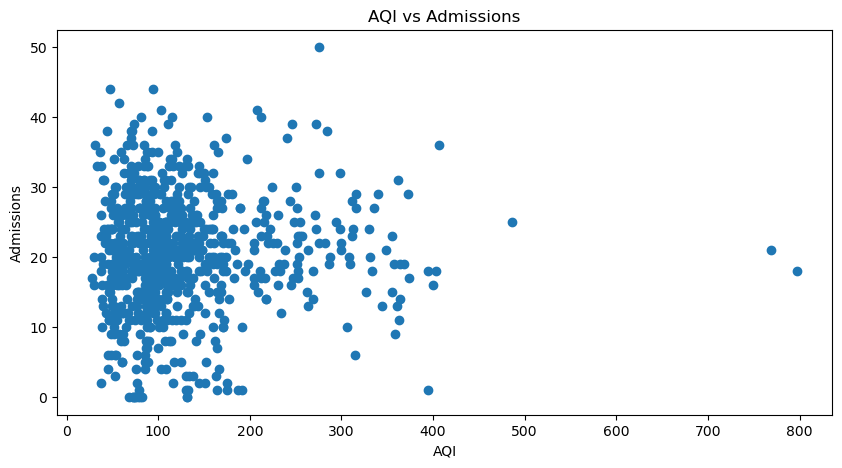

In [72]:
# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.scatter(
    merged['AQI'],
    merged['Admissions']
)

plt.xlabel("AQI")
plt.ylabel("Admissions")
plt.title("AQI vs Admissions")

plt.show()

In [74]:
merged['Deaths'].describe()

count    737.000000
mean       0.487110
std        0.759118
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        5.000000
Name: Deaths, dtype: float64

In [73]:
merged['Admissions'].describe()

count    737.000000
mean      20.420624
std        8.498370
min        0.000000
25%       16.000000
50%       20.000000
75%       26.000000
max       50.000000
Name: Admissions, dtype: float64

In [75]:
merged[['DATE','Admissions','Deaths']].sample(20)

,DATE,Admissions,Deaths
583,2018-10-29,34.0,0.0
524,2018-08-31,16.0,1.0
635,2018-12-20,33.0,2.0
515,2018-08-22,27.0,0.0
234,2017-11-14,19.0,0.0
390,2018-04-19,18.0,0.0
78,2017-11-06,25.0,0.0
176,2017-09-17,11.0,1.0
415,2018-05-14,26.0,2.0
143,2017-08-15,9.0,1.0


In [76]:
disease_cols = [
    'DM','HTN','CAD','CKD',
    'HEART FAILURE','STEMI','AKI'
]

for disease in disease_cols:
    mortality_rate = (
        admission.groupby(disease)['OUTCOME']
        .apply(lambda x: (x=='EXPIRY').mean()*100)
    )

    print("\n", disease)
    print(mortality_rate)


 DM
DM
0    7.617261
1    5.748479
Name: OUTCOME, dtype: float64

 HTN
HTN
0    8.455746
1    5.485893
Name: OUTCOME, dtype: float64

 CAD
CAD
0    11.947753
1     4.577765
Name: OUTCOME, dtype: float64

 CKD
CKD
0     6.208207
1    14.387097
Name: OUTCOME, dtype: float64

 HEART FAILURE
HEART FAILURE
0     4.135406
1    14.075861
Name: OUTCOME, dtype: float64

 STEMI
STEMI
0    6.617484
1    9.445958
Name: OUTCOME, dtype: float64

 AKI
AKI
0     4.382600
1    16.210046
Name: OUTCOME, dtype: float64


In [77]:
mortality_age = admission.groupby(
    'Age_Group'
)['OUTCOME'].apply(
    lambda x:(x=='EXPIRY').mean()*100
)

mortality_age

KeyError: 'Age_Group'

In [78]:
admission.groupby(
    'OUTCOME'
)['duration of intensive unit stay'].mean()

OUTCOME
DAMA         3.983259
DISCHARGE    3.748473
EXPIRY       4.346606
Name: duration of intensive unit stay, dtype: float64

In [79]:
admission.groupby(
    'OUTCOME'
)['DURATION OF STAY'].mean()

OUTCOME
DAMA         5.070312
DISCHARGE    6.589197
EXPIRY       5.337557
Name: DURATION OF STAY, dtype: float64

In [80]:
admission.groupby(
    'SMOKING'
)['OUTCOME'].apply(
    lambda x:(x=='EXPIRY').mean()*100
)

KeyError: 'SMOKING'

In [81]:
admission.groupby(
    'ALCOHOL'
)['OUTCOME'].apply(
    lambda x:(x=='EXPIRY').mean()*100
)

ALCOHOL
0    7.410423
1    1.273262
Name: OUTCOME, dtype: float64

In [82]:
admission.groupby(
    'RURAL'
)['OUTCOME'].apply(
    lambda x:(x=='EXPIRY').mean()*100
)

RURAL
R    7.554348
U    6.847727
Name: OUTCOME, dtype: float64

In [83]:
admission['Age_Group'] = pd.cut(
    admission['AGE'],
    bins=[0,18,35,50,65,100],
    labels=['0-18','19-35','36-50','51-65','65+']
)

In [84]:
mortality_age = admission.groupby(
    'Age_Group'
)['OUTCOME'].apply(
    lambda x:(x=='EXPIRY').mean()*100
)

print(mortality_age)

Age_Group
0-18     8.219178
19-35    5.614035
36-50    5.142371
51-65    5.885824
65+      9.147157
Name: OUTCOME, dtype: float64


/var/folders/b5/3pmv91ws4z59f27_4r75x0kc0000gn/T/ipykernel_65544/2937856743.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mortality_age = admission.groupby(


In [85]:
print(admission.columns.tolist())

['SNO', 'MRD No.', 'D.O.A', 'D.O.D', 'AGE', 'GENDER', 'RURAL', 'TYPE OF ADMISSION-EMERGENCY/OPD', 'month year', 'DURATION OF STAY', 'duration of intensive unit stay', 'OUTCOME', 'SMOKING ', 'ALCOHOL', 'DM', 'HTN', 'CAD', 'PRIOR CMP', 'CKD', 'HB', 'TLC', 'PLATELETS', 'GLUCOSE', 'UREA', 'CREATININE', 'BNP', 'RAISED CARDIAC ENZYMES', 'EF', 'SEVERE ANAEMIA', 'ANAEMIA', 'STABLE ANGINA', 'ACS', 'STEMI', 'ATYPICAL CHEST PAIN', 'HEART FAILURE', 'HFREF', 'HFNEF', 'VALVULAR', 'CHB', 'SSS', 'AKI', 'CVA INFRACT', 'CVA BLEED', 'AF', 'VT', 'PSVT', 'CONGENITAL', 'UTI', 'NEURO CARDIOGENIC SYNCOPE', 'ORTHOSTATIC', 'INFECTIVE ENDOCARDITIS', 'DVT', 'CARDIOGENIC SHOCK', 'SHOCK', 'PULMONARY EMBOLISM', 'CHEST INFECTION', 'Age_Group']


In [86]:
[col for col in admission.columns if 'SMOK' in col.upper()]

['SMOKING ']

In [87]:
total_patients = len(admission)

total_deaths = (admission['OUTCOME']=='EXPIRY').sum()

mortality_rate = (
    total_deaths / total_patients
)*100

avg_los = admission['DURATION OF STAY'].mean()

avg_icu = admission[
    'duration of intensive unit stay'
].mean()

print(total_patients)
print(total_deaths)
print(mortality_rate)
print(avg_los)
print(avg_icu)

15757
1105
7.012756235323983
6.4150536269594465
3.803769753125595


In [88]:
total_patients = len(admission)

total_deaths = (
    admission['OUTCOME'] == 'EXPIRY'
).sum()

mortality_rate = (
    total_deaths / total_patients
) * 100

print("Total Patients:", total_patients)
print("Total Deaths:", total_deaths)
print("Mortality Rate:", round(mortality_rate,2), "%")

Total Patients: 15757
Total Deaths: 1105
Mortality Rate: 7.01 %


In [89]:
disease_cols = [
    'DM','HTN','CAD',
    'CKD','HEART FAILURE',
    'STEMI','AKI'
]

for disease in disease_cols:

    prevalence = (
        admission[disease].sum()
        / len(admission)
    ) * 100

    print(
        disease,
        round(prevalence,2),
        "%"
    )

DM 32.35 %
HTN 48.59 %
CAD 66.96 %
CKD 9.84 %
HEART FAILURE 28.95 %
STEMI 13.97 %
AKI 22.24 %


In [90]:
risk_table = []

for disease in disease_cols:

    mortality = (
        admission
        .groupby(disease)['OUTCOME']
        .apply(
            lambda x:
            (x=='EXPIRY').mean()*100
        )
    )

    risk_table.append([
        disease,
        mortality[1]
    ])

In [91]:
risk_df = pd.DataFrame(
    risk_table,
    columns=[
        'Disease',
        'Mortality_Rate'
    ]
)

risk_df.sort_values(
    'Mortality_Rate',
    ascending=False
)

,Disease,Mortality_Rate
6,AKI,16.210046
3,CKD,14.387097
4,HEART FAILURE,14.075861
5,STEMI,9.445958
0,DM,5.748479
1,HTN,5.485893
2,CAD,4.577765


In [92]:
gender_mortality = (
    admission.groupby(
        'GENDER'
    )['OUTCOME']
    .apply(
        lambda x:
        (x=='EXPIRY').mean()*100
    )
)

print(gender_mortality)

GENDER
F    6.988035
M    7.027027
Name: OUTCOME, dtype: float64


In [94]:
admission['Age_Group'] = pd.cut(
    admission['AGE'],
    bins=[0,18,35,50,65,100],
    labels=[
        '0-18',
        '19-35',
        '36-50',
        '51-65',
        '65+'
    ]
)
age_mortality = (
    admission.groupby(
        'Age_Group'
    )['OUTCOME']
    .apply(
        lambda x:
        (x=='EXPIRY').mean()*100
    )
)

print(age_mortality)

Age_Group
0-18     8.219178
19-35    5.614035
36-50    5.142371
51-65    5.885824
65+      9.147157
Name: OUTCOME, dtype: float64


/var/folders/b5/3pmv91ws4z59f27_4r75x0kc0000gn/T/ipykernel_65544/4019327353.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  admission.groupby(


In [95]:
risk_df.to_csv(
    "Disease_Mortality_Risk.csv",
    index=False
)

In [96]:
daily_admissions.to_csv(
    "Daily_Admissions.csv",
    index=False
)

In [97]:
daily_deaths.to_csv(
    "Daily_Deaths.csv",
    index=False
)

In [98]:
merged.to_csv(
    "Healthcare_Pollution_Merged.csv",
    index=False
)

In [100]:
import os

print(os.getcwd())

/Users/ayushh.h


In [101]:
import os

print(os.listdir())

['KayakalpClinic.ipynb', 'Neural_Network_for_Diabetes_Prediction (1).ipynb', 'Health_Data_Preprocessing_Explained(1).ipynb', 'Untitled10.ipynb', '.Rhistory', 'Untitled7.ipynb', 'Fourier_transformation.ipynb', 'DigitClassification_with_assigment.ipynb', '.config', '.junie', 'Music', 'DR Gargi March.ipynb', '.condarc', 'Untitled12.ipynb', 'TSA of daily heart rate (ayush).ipynb', '.mysqlsh-wb', 'Untitled5.ipynb', 'Copy_of_Deep_Learning_Assing_1.ipynb', 'Untitled1.ipynb', 'Untitled16.ipynb', 'perceptron based.ipynb', '.DS_Store', 'final_patient_predictions.xlsx', 'cleaned_hospital_data.csv', '.CFUserTextEncoding', 'Output1.spv', '.xonshrc', 'Basics R.R', 'anaconda_projects', 'Untitled3.ipynb', 'Untitled14.ipynb', 'Untitled.ipynb', 'Neural_Network_for_Diabetes_Prediction.ipynb', '.zshrc', 'KayaKalap_Client.ipynb', 'Untitled4.ipynb', '.local', 'Untitled13.ipynb', '8_03_Working_with_Image_Data.ipynb', 'Untitled6.ipynb', 'neural network.ipynb', 'Pictures', 'Untitled11.ipynb', '01_kpis.csv', 'K

In [102]:
print(risk_df.head())

         Disease  Mortality_Rate
0             DM        5.748479
1            HTN        5.485893
2            CAD        4.577765
3            CKD       14.387097
4  HEART FAILURE       14.075861
